# Week 8 — Evaluation Expansion

This notebook takes the winning model from `05_advanced_models.ipynb` — **XGBoost** on the
**V2 (21-feature)** set (`max_depth=7`, `n_estimators=400`, `learning_rate=0.1`), which beat every
other model/feature-set combination on test MdAPE (0.0812 vs. the next-best tuned Random Forest at
0.0841) — and expands the evaluation beyond the single top-line number:

1. Refit that exact model (same hyperparameters, same feature set, same `RANDOM_STATE`) so this
   notebook is self-contained and reproducible without re-running the full grid search in
   `05_advanced_models.ipynb`.
2. Report the full metric suite — **R², MAPE, MdAPE, MAE** — on test, together.
3. Break error out **by price band (quintiles)** and **by geography (City)**, per the AVM
   best-practices doc's requirement not to rely on a single top-line number.
4. Summarize what the breakdowns say about where the model is (and isn't) trustworthy.
5. Export everything to `metrics_summary.csv`.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from xgboost import XGBRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_absolute_percentage_error

pd.set_option('display.max_columns', 50)
RANDOM_STATE = 42


def median_absolute_percentage_error(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    return np.median(np.abs((y_true - y_pred) / y_true))


def metrics_row(y_true, y_pred):
    return {
        'N': len(y_true),
        'R2': r2_score(y_true, y_pred),
        'MAE': mean_absolute_error(y_true, y_pred),
        'MAPE': mean_absolute_percentage_error(y_true, y_pred),
        'MdAPE': median_absolute_percentage_error(y_true, y_pred),
    }

## Load Data & Refit Winning Model

Same `engineered_train_set_v2.csv` / `engineered_test_set_v2.csv` files and `newest_feature_cols`
list as `05_advanced_models.ipynb` (train = 2023-06 through 2025-05, test = 2025-06, touched once).
Hyperparameters below are copied verbatim from that notebook's "Best Configs" cell — not re-tuned
here, since tuning already happened there against a validation month carved out of train.

In [2]:
train = pd.read_csv("engineered_train_set_v2.csv", low_memory=False)
test = pd.read_csv("engineered_test_set_v2.csv", low_memory=False)

old_feature_cols = ['Latitude', 'Longitude', 'LivingArea', 'ParkingTotal', 'LotSizeAcres', 'YearBuilt',
                     'BathroomsTotalInteger', 'BedroomsTotal', 'Stories', 'LotSizeArea', 'MainLevelBedrooms',
                     'AssociationFee', 'LotSizeSquareFeet', 'Levels_MultiSplit', 'NumLevels']
new_feature_cols = old_feature_cols + ['BedBathRatio', 'PropertyAge', 'SchoolDistrict_MeanPrice']
FEATURE_COLS = new_feature_cols + ['CloseMonth_sin', 'CloseMonth_cos', 'DistanceToNearestCBD_km']

X_train, y_train = train[FEATURE_COLS], train['ClosePrice']
X_test, y_test = test[FEATURE_COLS], test['ClosePrice']

model = XGBRegressor(max_depth=7, n_estimators=400, learning_rate=0.1, n_jobs=8,
                      objective='reg:squarederror', random_state=RANDOM_STATE)
model.fit(X_train, y_train)

test_eval = test.copy()
test_eval['pred'] = model.predict(X_test)

print(f"Train: {len(train)} rows, Test: {len(test)} rows, Features: {len(FEATURE_COLS)}")

Train: 336198 rows, Test: 10581 rows, Features: 21


## Overall Metrics (Test)

R², MAE, MAPE, MdAPE together, per the best-practices doc — MdAPE is the headline number since
real-estate errors are right-skewed and multi-scale, but the other three matter for tail risk
(MAE/RMSE-style) and a dollar-denominated read for non-technical stakeholders.

In [3]:
overall_metrics = metrics_row(test_eval['ClosePrice'], test_eval['pred'])
overall_df = pd.DataFrame([{'Segment Type': 'Overall', 'Segment': 'All', **overall_metrics}])
overall_df

,Segment Type,Segment,N,R2,MAE,MAPE,MdAPE
0,Overall,All,10581,0.909705,115315.152823,0.117218,0.081222


## Error by Price Band (Quintiles)

Test-set `ClosePrice` split into 5 equal-count quintiles (Q1 = cheapest fifth, Q5 = most expensive
fifth). Note **R² is not a meaningful metric within a narrow price band** — once a band's own price
range is small, there's little variance left for the model to "explain" relative to the band mean,
which is why R² goes negative for the middle quintiles below even though absolute/percentage error
is low there. MAPE/MdAPE are the metrics to trust at this granularity.

In [4]:
test_eval['PriceBand'] = pd.qcut(test_eval['ClosePrice'], 5, labels=[f'Q{i+1}' for i in range(5)])

band_rows = []
for band, g in test_eval.groupby('PriceBand', observed=True):
    row = {'Segment Type': 'Price Band',
           'Segment': f"{band} (${g['ClosePrice'].min():,.0f}–${g['ClosePrice'].max():,.0f})",
           **metrics_row(g['ClosePrice'], g['pred'])}
    band_rows.append(row)
priceband_df = pd.DataFrame(band_rows)
priceband_df

,Segment Type,Segment,N,R2,MAE,MAPE,MdAPE
0,Price Band,"Q1 ($29,900–$560,000)",2119,0.236145,57756.171132,0.167461,0.087328
1,Price Band,"Q2 ($561,000–$759,000)",2115,-1.734469,64111.004457,0.096916,0.069083
2,Price Band,"Q3 ($759,900–$990,000)",2115,-2.174636,81565.693632,0.094149,0.071058
3,Price Band,"Q4 ($992,500–$1,450,000)",2142,-0.860688,135529.231501,0.112124,0.089545
4,Price Band,"Q5 ($1,450,700–$3,450,000)",2090,0.549179,238925.586154,0.115386,0.096800


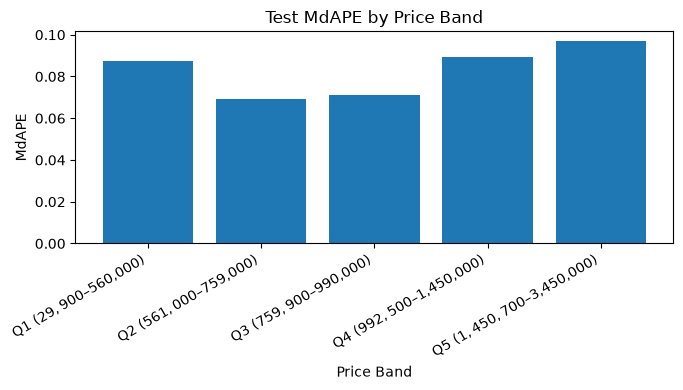

In [5]:
plt.figure(figsize=(7, 4))
plt.bar(priceband_df['Segment'], priceband_df['MdAPE'])
plt.ylabel('MdAPE')
plt.xlabel('Price Band')
plt.title('Test MdAPE by Price Band')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

## Error by Geography (City)

Restricted to cities with at least `MIN_CITY_N = 30` test-set sales — the "where sample size
allows" qualifier from the best-practices doc. `City` (579 distinct values, 10 missing in test) is
used rather than county, since no raw county column survived feature engineering (only the
already-aggregated `CountyOrParish_MeanPrice`).

In [6]:
MIN_CITY_N = 30

geo_rows = []
for city, g in test_eval.groupby('City'):
    if len(g) < MIN_CITY_N:
        continue
    geo_rows.append({'Segment Type': 'City', 'Segment': city, **metrics_row(g['ClosePrice'], g['pred'])})
geo_df = pd.DataFrame(geo_rows).sort_values('MdAPE').reset_index(drop=True)

print(f"{len(geo_df)} of {test_eval['City'].nunique()} cities have >= {MIN_CITY_N} test-set sales "
      f"(covering {geo_df['N'].sum()} of {len(test_eval)} test rows)")
print("\nBest 10 (lowest MdAPE):")
display(geo_df.head(10))
print("\nWorst 10 (highest MdAPE):")
display(geo_df.tail(10))

104 of 579 cities have >= 30 test-set sales (covering 6691 of 10581 test rows)

Best 10 (lowest MdAPE):


,Segment Type,Segment,N,R2,MAE,MAPE,MdAPE
0,City,Winchester,49,0.821091,26127.567602,0.044292,0.028796
1,City,Beaumont,37,0.736302,28892.856419,0.051916,0.039883
2,City,Hesperia,45,0.699842,33997.986806,0.087773,0.043217
3,City,Corona,90,0.874762,52533.301389,0.060255,0.044146
4,City,Apple Valley,48,0.742035,39610.138997,0.101300,0.045395
5,City,Rancho Santa Margarita,41,0.880282,86014.923780,0.077640,0.045534
6,City,Chino,36,0.909987,49688.089410,0.061868,0.048199
7,City,Santee,41,0.841091,63207.018293,0.079822,0.048455
8,City,Saugus,34,0.970154,49309.988971,0.055858,0.048839
9,City,Antioch,51,0.855161,37859.358456,0.077384,0.049068



Worst 10 (highest MdAPE):


,Segment Type,Segment,N,R2,MAE,MAPE,MdAPE
94,City,Alameda,37,0.790056,171722.005068,0.134671,0.113131
95,City,Palm Desert,55,0.686189,104450.892614,0.161327,0.114746
96,City,Los Angeles,379,0.840645,193982.553760,0.145339,0.115617
97,City,Santa Cruz,34,0.752998,177125.959559,0.128509,0.116928
98,City,Paso Robles,36,0.802179,105024.496962,0.156125,0.119648
99,City,Walnut Creek,79,0.870555,146226.257516,0.161680,0.121653
100,City,Oakland,148,0.827017,191921.758446,0.210754,0.138346
101,City,Laguna Woods,32,0.679962,72339.809784,0.226892,0.148896
102,City,Palm Springs,61,0.833633,156260.780994,0.190121,0.159391
103,City,San Clemente,40,0.620435,287955.834375,0.182271,0.169537


## Export `metrics_summary.csv`

Overall + price-band + city breakdowns, stacked into one flat table.

In [7]:
metrics_summary = pd.concat([overall_df, priceband_df, geo_df], ignore_index=True)
metrics_summary = metrics_summary[['Segment Type', 'Segment', 'N', 'R2', 'MAE', 'MAPE', 'MdAPE']]
metrics_summary.to_csv('metrics_summary.csv', index=False)

print(f"Wrote metrics_summary.csv: {len(metrics_summary)} rows")
metrics_summary.head(10)

Wrote metrics_summary.csv: 110 rows


,Segment Type,Segment,N,R2,MAE,MAPE,MdAPE
0,Overall,All,10581,0.909705,115315.152823,0.117218,0.081222
1,Price Band,"Q1 ($29,900–$560,000)",2119,0.236145,57756.171132,0.167461,0.087328
2,Price Band,"Q2 ($561,000–$759,000)",2115,-1.734469,64111.004457,0.096916,0.069083
3,Price Band,"Q3 ($759,900–$990,000)",2115,-2.174636,81565.693632,0.094149,0.071058
4,Price Band,"Q4 ($992,500–$1,450,000)",2142,-0.860688,135529.231501,0.112124,0.089545
5,Price Band,"Q5 ($1,450,700–$3,450,000)",2090,0.549179,238925.586154,0.115386,0.096800
6,City,Winchester,49,0.821091,26127.567602,0.044292,0.028796
7,City,Beaumont,37,0.736302,28892.856419,0.051916,0.039883
8,City,Hesperia,45,0.699842,33997.986806,0.087773,0.043217
9,City,Corona,90,0.874762,52533.301389,0.060255,0.044146


## Key Insights

- **Overall**: R² = 0.910, MAE = \$115,315, MAPE = 11.7%, **MdAPE = 8.1%** on the June 2025 test
  month — consistent with the number reported in `05_advanced_models.ipynb`.
- **Price bands — the model is best in the middle, worst at both tails**: MdAPE by quintile is
  Q1 8.7% → Q2 6.9% → Q3 7.1% → Q4 9.0% → Q5 9.7%. The cheapest fifth (< ~$560K, largely
  condos/entry-level and manufactured homes) and the most expensive fifth (> ~$1.45M, luxury/
  custom homes) both price worse than the ~$560K–$990K middle bands. This matches the usual AVM
  pattern: comps get thinner and homes get more heterogeneous at both extremes, so the model has
  less to learn from. R² is not informative here (it goes negative in the middle bands) precisely
  *because* those bands are priced tightly — low residual error relative to a narrow price range,
  which is a good sign, not a bad one; R²'s denominator (within-band variance) just breaks down as
  a yardstick once the band is narrow.
- **Geography — inland/suburban markets outperform coastal/luxury markets**: the lowest-MdAPE
  cities (e.g. Winchester, Beaumont, Hesperia, Corona, Apple Valley — Inland Empire suburbs with
  more homogeneous, tract-built housing stock) sit around 3–5% MdAPE, while the highest-MdAPE
  cities (e.g. San Clemente, Palm Springs, Laguna Woods, Oakland, Walnut Creek — coastal, luxury,
  or otherwise architecturally varied markets) run 12–17% MdAPE. This lines up with the price-band
  finding: the cities the model struggles with tend to have higher, more dispersed price levels.
- **Production implication**: treat the model's point estimate as most reliable for
  \$560K–\$990K homes in tract-style suburban markets, and flag predictions for manual review below
  ~$560K, above ~$1.45M, or in high-MdAPE cities — a single global MdAPE understates the error a
  user would see on those segments.
- **Caveat**: several city-level buckets (`MIN_CITY_N = 30`) are still small samples for a
  percentage-error metric; per the best-practices doc's rolling-origin-backtest guidance, these
  city/price-band splits should be re-checked at 2–3 additional historical cutoffs before treating
  any single city's ranking as stable rather than a one-month artifact.